In [1]:
import torch
import math
import matplotlib.pyplot as plt

from src.radials.unimodal import UniModalRadial

In [2]:
class CenteredGaussianEllipsoidRadial(UniModalRadial):
    def __init__(self, cov, p=0.95):
        super().__init__(cov.shape[0])
        self.cov = cov
        self.p = p
        
        # construct Sigma from cov
        self.Sigma = self.construct_Sigma()
        self.Sigma_inv = torch.linalg.inv(self.Sigma)

    def forward(self, theta: torch.Tensor):
        t = self.compute_intersect(theta)
        return t

    def compute_intersect(self, theta: torch.Tensor):
        """
        :param theta: N x d tensor
        :return: N tensor
        """
        # computes smallest t>=0 such that t* theta - mu is in the ellipsoid defined by Sigma, i.e., (t*theta - mu)^T Sigma^{-1} (t*theta - mu) = 1
        # this is a quadratic equation in t, which we can solve using the quadratic formula
        a = torch.einsum("ij,jk,ik->i", theta, self.Sigma_inv, theta)
        discriminant =  4 * a 
        assert (discriminant >= 0).all(), "discriminant must be non-negative"
        t = (torch.sqrt(discriminant)) / (2 * a)
        assert (t >= 0).all(), "t must be non-negative"
        return t
    
    def normal_quantile(self, eps=1e-10):
        """
        Approximate Phi^{-1}(p) using erfinv; fully differentiable.
        p can be tensor or scalar in (0,1).
        """
        p = torch.as_tensor(self.p)
        p = torch.clamp(p, eps, 1 - eps)
        return math.sqrt(2.0) * torch.erfinv(2.0 * p - 1.0)


    def gaussian_ellipsoid_radius_approx(self, wh=False):
        """
        Differentiable approximation of r such that
        P(X^T Sigma^{-1} X <= r^2) ~= p for X ~ N(0, Sigma) in R^d.

        d: scalar or tensor of dimensions (degrees of freedom)
        p: scalar or tensor of probabilities in (0,1)
        wh: if True, use Wilson–Hilferty; else simple normal approx.
        """
        d = torch.as_tensor(self.d, dtype=torch.get_default_dtype())
        z = self.normal_quantile().to(d.dtype)

        if not wh:
            # Simple normal approximation: chi2_{d,p} ≈ d + sqrt(2d)*z
            q = d + torch.sqrt(2.0 * d) * z
        else:
            # Wilson–Hilferty: chi2_{d,p} ≈ d (1 - 2/(9d) + z sqrt(2/(9d)))^3
            d_safe = torch.clamp(d, min=1e-6)
            term = 1.0 - 2.0 / (9.0 * d_safe) + z * torch.sqrt(2.0 / (9.0 * d_safe))
            q = d_safe * term.pow(3)

        q = torch.clamp(q, min=0.0)
        return torch.sqrt(q)
    
    def construct_Sigma(self):
        r = self.gaussian_ellipsoid_radius_approx()
        return r ** 2 * self.cov

In [ ]:
class NonCenteredGaussianEllipsoidRadial(UniModalRadial):
    def __init__(self, mu: torch.Tensor, cov: torch.Tensor, c=4/3, p=0.99):
        assert mu.shape[0] == cov.shape[0] == cov.shape[1], "mu and cov must have the same dimension"
        assert c > 1, "c must be greater than 1"
        assert mu.norm(2) > 0, "mu must be non-zero"
        super().__init__(mu.shape[0])
        self.mu = mu
        self.cov = cov
        self.c = c
        self.p = p

        # construct Sigma from cov and mu
        self.Sigma = self.construct_Sigma()
        self.Sigma_inv = torch.linalg.inv(self.Sigma)

    def forward(self, theta: torch.Tensor):
        t = self.compute_intersect(theta)
        return t

    def compute_intersect(self, theta: torch.Tensor):
        """
        :param theta: N x d tensor
        :return: N tensor
        """
        # computes smallest t>=0 such that t* theta - mu is in the ellipsoid defined by Sigma, i.e., (t*theta - mu)^T Sigma^{-1} (t*theta - mu) = 1
        # this is a quadratic equation in t, which we can solve using the quadratic formula
        a = torch.einsum("ij,jk,ik->i", theta, self.Sigma_inv, theta)
        b = -2 * torch.einsum("ij,jk,k->i", theta, self.Sigma_inv, self.mu)
        c = torch.einsum("i,i->", self.mu, self.Sigma_inv @ self.mu) - 1
        discriminant = b ** 2 - 4 * a * c
        assert (discriminant >= 0).all(), "discriminant must be non-negative"
        t = (-b + torch.sqrt(discriminant)) / (2 * a)
        assert (t >= 0).all(), "t must be non-negative"
        return t
    
    def normal_quantile(self, eps=1e-10):
        """
        Approximate Phi^{-1}(p) using erfinv; fully differentiable.
        p can be tensor or scalar in (0,1).
        """
        p = torch.as_tensor(self.p)
        p = torch.clamp(p, eps, 1 - eps)
        return math.sqrt(2.0) * torch.erfinv(2.0 * p - 1.0)


    def gaussian_ellipsoid_radius_approx(self, wh=False):
        """
        Differentiable approximation of r such that
        P(X^T Sigma^{-1} X <= r^2) ~= p for X ~ N(0, Sigma) in R^d.

        d: scalar or tensor of dimensions (degrees of freedom)
        p: scalar or tensor of probabilities in (0,1)
        wh: if True, use Wilson–Hilferty; else simple normal approx.
        """
        d = torch.as_tensor(self.d, dtype=torch.get_default_dtype())
        z = self.normal_quantile().to(d.dtype)

        if not wh:
            # Simple normal approximation: chi2_{d,p} ≈ d + sqrt(2d)*z
            q = d + torch.sqrt(2.0 * d) * z
        else:
            # Wilson–Hilferty: chi2_{d,p} ≈ d (1 - 2/(9d) + z sqrt(2/(9d)))^3
            d_safe = torch.clamp(d, min=1e-6)
            term = 1.0 - 2.0 / (9.0 * d_safe) + z * torch.sqrt(2.0 / (9.0 * d_safe))
            q = d_safe * term.pow(3)

        q = torch.clamp(q, min=0.0)
        return torch.sqrt(q)

    def construct_Sigma(self):
        r = self.gaussian_ellipsoid_radius_approx()
        lambda_1 = torch.maximum(self.c ** 2 * self.mu.norm(2) ** 2, r * torch.linalg.eigvals(self.cov).real.max())
        mu_o_mu = torch.outer(self.mu, self.mu) / self.mu.norm(2) ** 2
        Sigma = lambda_1 * mu_o_mu + r ** 2 * (torch.eye(self.mu.shape[0]) - mu_o_mu) @ self.cov @ (torch.eye(self.mu.shape[0]) - mu_o_mu)
        return Sigma

In [4]:
mu = torch.tensor([1.0, 1.0])
cov = torch.tensor([[0.25, 0.0], [0.0, 0.25]])
p = 0.95

radial_c = CenteredGaussianEllipsoidRadial(cov, p=p)
radial_nc = NonCenteredGaussianEllipsoidRadial(mu, cov, p=p)

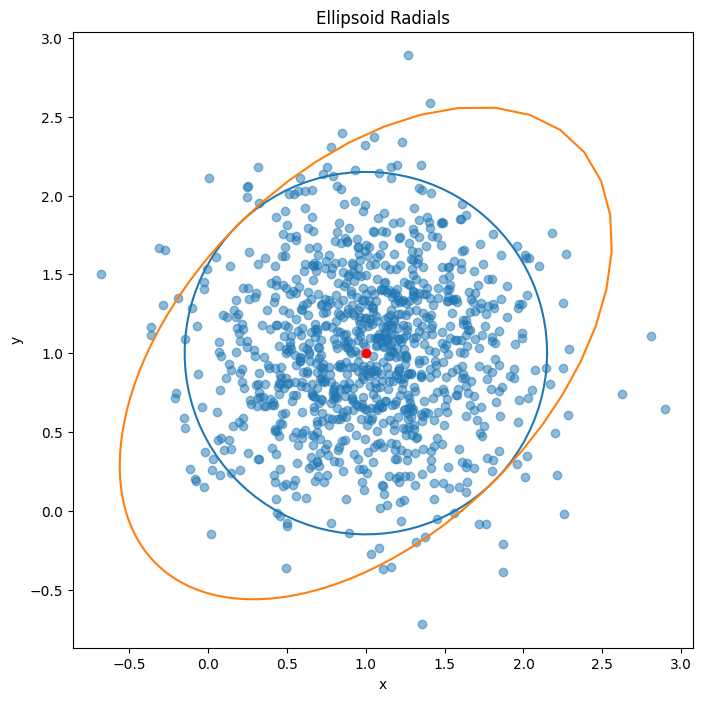

In [ ]:
# plot the original ellipsoid defined the cov and translater dna the one by the radial through mapping the unit circle and translating it
theta = torch.linspace(0, 2 * torch.pi, 100)
circle = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)
# gaussian ellipsoid defined by cov and centered at mu
ellipsoid_c = radial_c(circle).unsqueeze(1) * circle + mu
# larger ellipsoid defined
ellipsoid_nc = radial_nc(circle).unsqueeze(1) * circle

data = torch.distributions.MultivariateNormal(mu, cov).sample((1000,))

plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label="Data")
plt.plot(ellipsoid_c[:, 0], ellipsoid_c[:, 1], label="Centered Gaussian Ellipsoid Radial")
plt.plot(ellipsoid_nc[:, 0], ellipsoid_nc[:, 1], label="Non-Centered Gaussian Ellipsoid Radial")
plt.scatter(mu[0], mu[1], color='red', label="mu")
plt.title("Ellipsoid Radials")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()


In [ ]:
# ideally, we'd have multiple sub classes as it is not clear whether we'd want to multiply by this number r in the first place. Better to check some data sets and see what happens to interpolation etc.